# 3. Model Analysis

This notebook analyzes model predictions and investigates individual creatures.

**Input:**
- `helper_files/engineered_features.parquet`
- `pickled_models/hp_model_cr*.pkl`

**Output:**
- `data/engineered_features.csv`
- `data/feature_contributions.csv`

## Imports and Configs

In [1]:
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path

In [2]:
# Detect execution context and set paths dynamically
sys.path.insert(0, '.')

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")

print("Imports successful")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models
Imports successful


In [3]:
# Add helper_files to path
if IN_NB_DIR is True:
    from helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")


Imports successful


## Load Data and Models

In [4]:
import_path = DATA_DIR + '/engineered_features.csv'
df = pd.read_csv(import_path)

In [5]:
import_path = DATA_DIR + '/feature_contributions.csv'
contributions_df = pd.read_csv(import_path)

In [6]:
phase3_features = get_phase3_features()

In [7]:
results = {}
load_path = PICKLED_MODELS_DIR + "/hp_model_tier.pkl"
# Save each model
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:

    filepath = load_path.replace('tier', tier)
    results[tier] = load_model(filepath)
    print(f"Loaded {tier} model to {filepath}")

print("\nAll models loaded successfully!")

Loaded cr1 model to ./pickled_models/hp_model_cr1.pkl
Loaded cr2 model to ./pickled_models/hp_model_cr2.pkl
Loaded cr3 model to ./pickled_models/hp_model_cr3.pkl
Loaded cr4 model to ./pickled_models/hp_model_cr4.pkl
Loaded cr5 model to ./pickled_models/hp_model_cr5.pkl

All models loaded successfully!


In [8]:
results['cr1'].keys()


dict_keys(['model', 'scaler', 'feature_names', 'train_count', 'test_r2', 'test_mae'])

## Model Analysis

In [9]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.4590
      Test MAE: 4.75 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.5626
      Test MAE: 11.34 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  0.4592
      Test MAE: 18.30 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  1.0000
      Test MAE: 0.00 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.9559
      Test MAE: 15.68 HP

All 5 models trained successfully!


In [10]:
# Display top feature coefficients for each tier
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:
    print(f"\n{tier.upper()} Top Features by Coefficient:")
    coefs = results[tier]['model'].coef_
    coef_df = pd.DataFrame({
        'feature': phase3_features,
        'coefficient': coefs
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print(coef_df.head(10).to_string(index=False))


CR1 Top Features by Coefficient:
                 feature  coefficient
  speed_ground_deviation     2.130887
condition_immunity_count     2.104978
     speed_fly_deviation     1.970148
      inflicts_petrified    -1.386234
     total_ability_count    -1.286235
      inflicts_paralyzed    -1.020293
  save_proficiency_count     0.821668
        has_spellcasting    -0.632587
             speed_climb    -0.596164
    movement_types_count     0.489542

CR2 Top Features by Coefficient:
                    feature  coefficient
     save_proficiency_count     4.841387
    skill_proficiency_count    -4.840424
                speed_climb    -4.309022
           inflicts_charmed    -3.235812
               speed_burrow    -3.168513
        vulnerability_count     3.164388
         inflicts_petrified    -2.717608
                trait_count     2.447788
     size_ordinal_deviation     2.279703
has_magic_resistance_scaled    -2.024539

CR3 Top Features by Coefficient:
                 feature  coe

## Investigate Specific Creatures

In [11]:
df[df['Name'].str.contains('Dragon')].head()

,Name,Type,Size,Challenge_Rating,cr_numeric,cr_tier,HP,hp_baseline,actual_hp,predicted_hp,...,inflicts_poisoned,inflicts_blinded,inflicts_charmed,inflicts_deafened,inflicts_frightened,inflicts_incapacitated,inflicts_paralyzed,inflicts_petrified,inflicts_restrained,inflicts_stunned
116,Brass Dragon Wyrmling,dragon,Medium,1,1.0,cr2,16 (3d8+3),49.5,16,21.806411,...,0,0,0,0,0,0,0,0,0,0
118,Copper Dragon Wyrmling,dragon,Medium,1,1.0,cr2,22 (4d8+4),49.5,22,22.827193,...,0,0,0,0,0,0,0,0,0,0
143,White Dragon Wyrmling,dragon,Medium,2,2.0,cr2,32 (5d8+10),54.0,32,32.387168,...,0,0,0,0,0,0,0,0,0,0
147,Black Dragon Wyrmling,dragon,Medium,2,2.0,cr2,33 (6d8+6),54.0,33,52.479692,...,0,0,0,0,0,0,0,0,0,0
148,Bronze Dragon Wyrmling,dragon,Medium,2,2.0,cr2,32 (5d8+10),54.0,32,47.604692,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Interactive investigation
# Uncomment and modify to investigate specific creatures:
investigate_creature('Imp', df, contributions_df)

  IMP (CR 1.0)

Actual HP:              10
Predicted HP:            5
Error:                  -5  ( -48.3%)

--------------------------------------------------------------------------------

PHASE 1: CR BASELINE
  HP Baseline (CR 1.0):                                50

PHASE 2: COMBAT STATS
  Feature: ac_deviation                   value:    1.0  hp impact:     -2
  Feature: attack_deviation               value:    0.0  hp impact:     -0
  Feature: dpr_deviation                  value:    4.0  hp impact:     -4
  Feature: save_dc_deviation              value:   -1.0  hp impact:      5
  Feature: has_flying                     value:    1.0  hp impact:     -4
  Feature: has_advantage_condition        value:    0.0  hp impact:     -0
  Feature: has_disadvantage_condition     value:    0.0  hp impact:      0
  Feature: has_attackers_advantage        value:    0.0  hp impact:      0
  Feature: inflicts_prone                 value:    0.0  hp impact:     -0
  ------------------------------

In [13]:
[c for c in contributions_df.columns if 'advant' in c]

['has_advantage_condition',
 'has_disadvantage_condition',
 'has_attackers_advantage',
 'phase2_advantage_contribution',
 'phase2_disadvantage_contribution',
 'phase2_attackers_advantage_contribution']

In [14]:
from notebooks.helper_files.parsers import has_advantage_condition


has_advantage_condition(df[df['Name'] == 'Cult Fanatic'])

0

In [15]:
# List worst predictions
# print("\nWorst Over-predictions (predicted > actual):")
# over_pred = df[df['hp_delta'] > 0].nlargest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(over_pred.to_string(index=False))

# print("\nWorst Under-predictions (predicted < actual):")
# under_pred = df[df['hp_delta'] < 0].nsmallest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(under_pred.to_string(index=False))

# print("\nBest Predictions:")
# df_check_best = df[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']].copy()
# df_check_best['hp_delta_pct_abs'] = df_check_best['hp_delta_pct'].abs()
# best = df_check_best.nsmallest(10, 'hp_delta_pct_abs')
# print(best.to_string(index=False))

# Deatiled Model Breakdown

In [16]:
analysis_dfs = analyze_predictions_by_cr(df)



CR < 1 - Best 10 Predictions:
        Name    CR  Actual_HP  Predicted_HP     Error
     Cultist 0.125          9      8.999998  0.000002
  Cockatrice 0.500         27     26.999964  0.000036
       Camel 0.125         15     14.815849  0.184151
    Warhorse 0.500         19     19.204124 -0.204124
    Shrieker 0.000         13     13.414076 -0.414076
        Pony 0.125         11     10.582680  0.417320
      Zombie 0.250         22     22.449193 -0.449193
Flying Sword 0.250         17     16.550772  0.449228
      Kobold 0.125          5      5.505598 -0.505598
        Wolf 0.250         11     10.484869  0.515131

CR < 1 - Worst 10 Predictions:
                 Name   CR  Actual_HP  Predicted_HP      Error
               Lemure 0.00         13      2.511355  10.488645
           Giant Wasp 0.50         13     24.090068 -11.090068
           Black Bear 0.50         19     30.273762 -11.273762
Giant Poisonous Snake 0.25         11     -0.409853  11.409853
            Crocodile 0.50  

In [17]:
analysis_dfs['cr2']['actual_hp'].value_counts()

actual_hp
52     10
45     10
22      6
33      5
59      5
27      5
58      4
39      4
26      4
85      3
42      3
32      3
66      3
67      3
68      3
36      2
60      2
37      2
38      2
76      2
97      2
75      2
44      1
90      1
16      1
28      1
34      1
10      1
7       1
65      1
84      1
78      1
19      1
93      1
82      1
120     1
Name: count, dtype: int64

In [18]:
_df_check = analysis_dfs['cr2']
_df_check[_df_check['actual_hp'] == 45]


,Name,Type,Size,Challenge_Rating,cr_numeric,cr_tier,HP,hp_baseline,actual_hp,predicted_hp,...,inflicts_paralyzed,inflicts_petrified,inflicts_restrained,inflicts_stunned,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
87,Ghost,undead,Medium,4,4.0,cr2,45 (10d8),100.8,45,45.739937,...,0,0,0,0,45,45.739937,4.0,-0.739937,0.739937,-1.644303
57,Rhinoceros,beast,Large,2,2.0,cr2,45 (6d10+12),54.0,45,48.647085,...,0,0,0,0,45,48.647085,2.0,-3.647085,3.647085,-8.104634
13,Giant Hyena,beast,Large,1,1.0,cr2,45 (6d10+12),49.5,45,49.820782,...,0,0,0,0,45,49.820782,1.0,-4.820782,4.820782,-10.712849
52,Merrow,monstrosity,Large,2,2.0,cr2,45 (6d10+12),54.0,45,52.536597,...,0,0,0,0,45,52.536597,2.0,-7.536597,7.536597,-16.747993
47,Ochre Jelly,ooze,Large,2,2.0,cr2,45 (6d10+12),54.0,45,36.530259,...,0,0,0,0,45,36.530259,2.0,8.469741,8.469741,18.821647
74,Wight,undead,Medium,3,3.0,cr2,45 (6d8+18),78.0,45,35.167996,...,0,0,0,0,45,35.167996,3.0,9.832004,9.832004,21.848897
50,Hunter Shark,beast,Large,2,2.0,cr2,45 (6d10+12),54.0,45,55.113204,...,0,0,0,0,45,55.113204,2.0,-10.113204,10.113204,-22.473786
66,Hell Hound,fiend,Medium,3,3.0,cr2,45 (7d8+14),78.0,45,56.647515,...,0,0,0,0,45,56.647515,3.0,-11.647515,11.647515,-25.883367
39,Silver Dragon Wyrmling,dragon,Medium,2,2.0,cr2,45 (6d8+18),54.0,45,29.220305,...,1,0,0,0,45,29.220305,2.0,15.779695,15.779695,35.065988
41,Centaur,monstrosity,Large,2,2.0,cr2,45 (6d10+12),54.0,45,27.377315,...,0,0,0,0,45,27.377315,2.0,17.622685,17.622685,39.161522



📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)


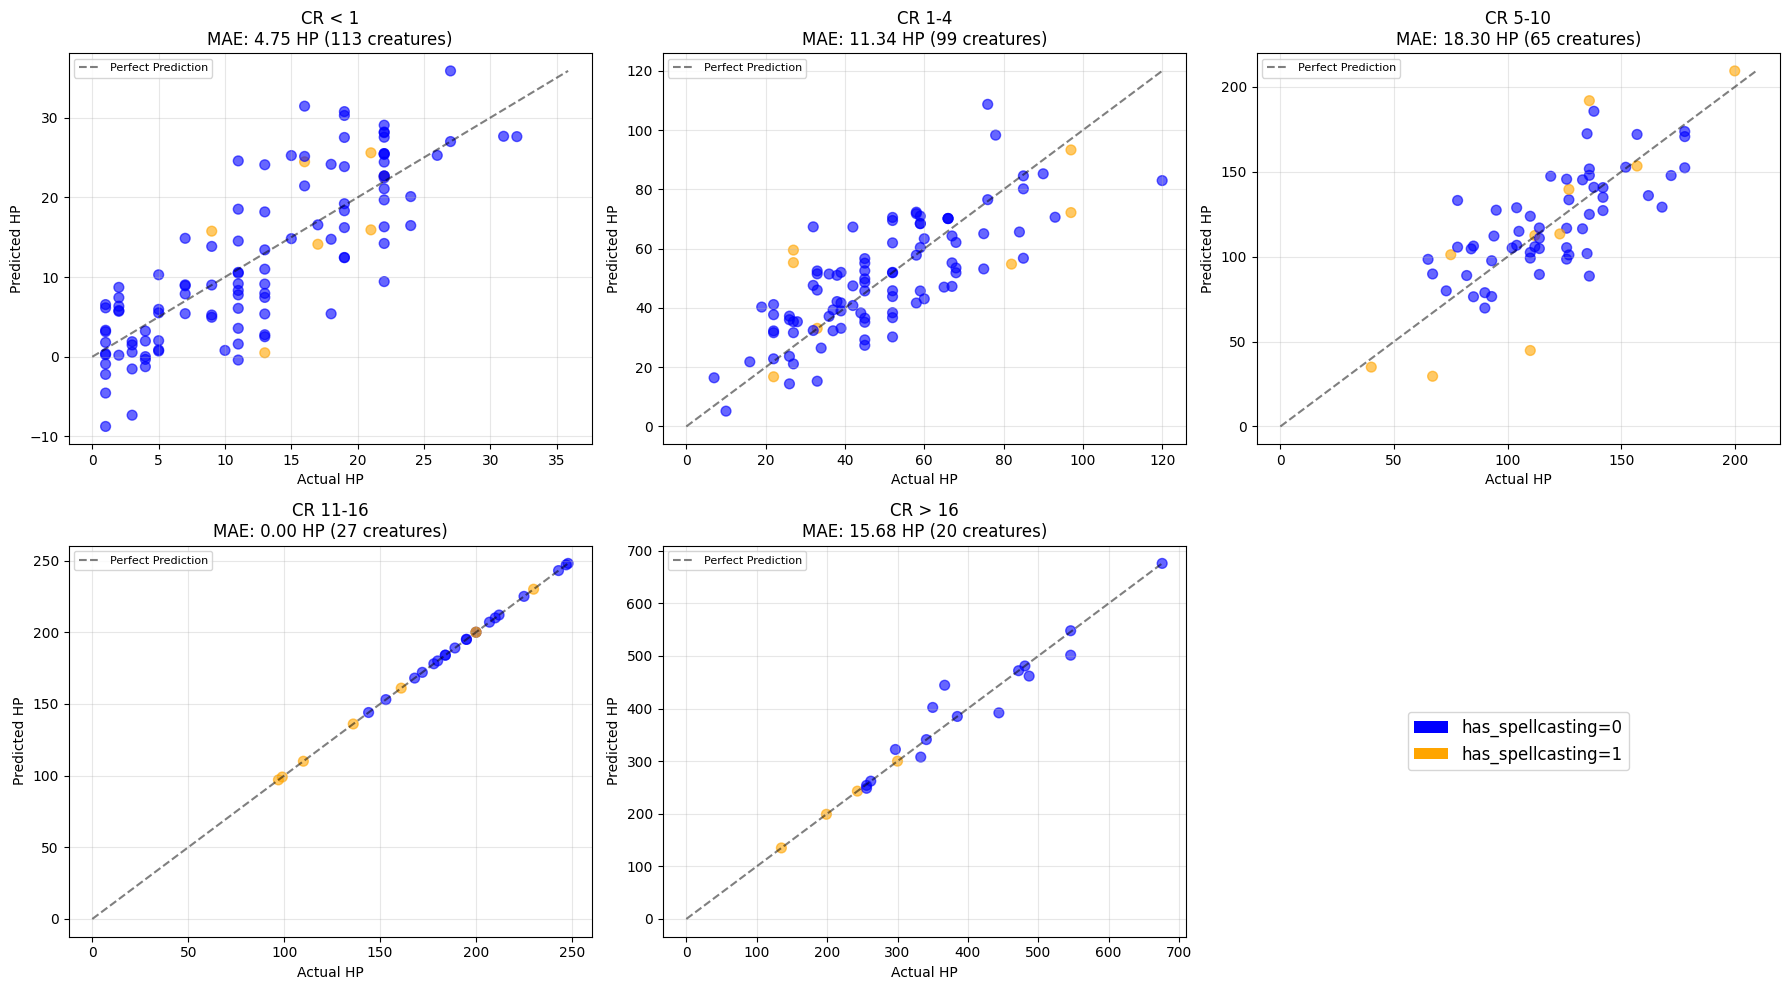

In [19]:
plot_performance_scatter(analysis_dfs, highlight_feature='has_spellcasting')


📊 VISUALIZATION: Error Distribution (5 CR Buckets)


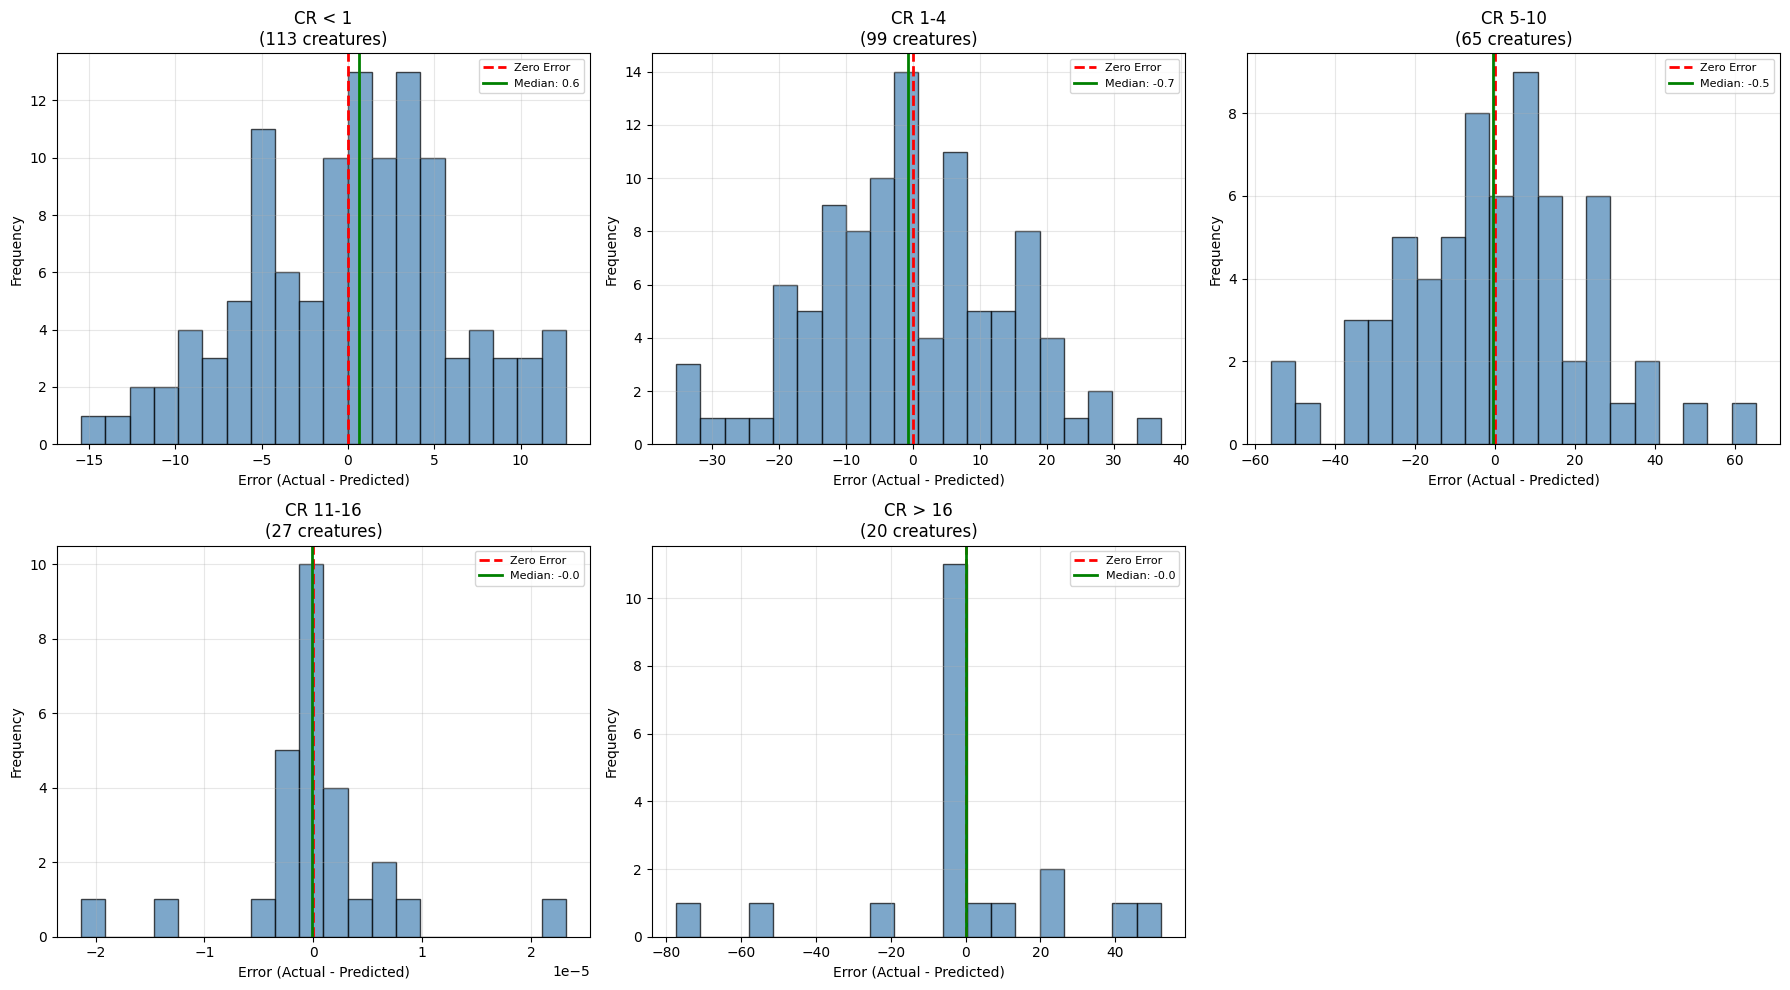

In [20]:
plot_error_hist(analysis_dfs)